## REQUIREMENTS

### This notebook is configured to load files from *metadata* and *data* folders. A small sample of INSTANCE data can be downloaded from http://repo.pi.ingv.it/instance/Instance_sample_dataset.tar.bz2. The downloaded file should be untarred in the *instance* directory cloned from GitHub.

### The collection of plots of this notebook is meant to be an overview of the characteristics of the metadata of INSTANCE.

Please note that the plots generated below adopt a very small subset of data and metadata randomly sampled from the whole dataset.

Last update: 2021/08/30

# **How to plot multiple waveforms in a single picture**

### This notebook provides some example to select waveform data according to the metadata provided. 

This has been used to generate figures 14, 15, 16 and 20 of the article:
Michelini A., Cianetti S., Gaviano S, Giunchi C., Jozinovic D. and V. Lauciani, INSTANCE - The Italian seismic dataset for machine learning, submitted to Earth System Science Data, 2021.

In [1]:
import string
import argparse as ap
import sys
import os
import numpy as np

import obspy
import obspy.core as oc
from obspy import read_inventory

# from datetime import datetime, timedelta
import time

import pylab as plt
import pandas as pd
import h5py


import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.dates import date2num
from matplotlib.lines import Line2D
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import datetime
import warnings

mpl.rcParams['pdf.fonttype'] = 42

## Define the path to metadata and hdf5 files

In [2]:
warnings.filterwarnings("ignore")

In [10]:
# directory PATH
METADIR = '../../data/sample/metadata'
HDFDIR = '../../data/sample/data'
FIGDIR='../output'

# file NAMES
# MetaData
events_metaname=os.path.join(METADIR,'metadata_Instance_events_10k.csv') # Either Counts and GroundMotion
noise_metaname=os.path.join(METADIR,'metadata_Instance_noise_1k.csv')
# HDF5
events_hdfname=os.path.join(HDFDIR,'Instance_events_counts_10k.hdf5')
gm_hdfname=os.path.join(HDFDIR,'Instance_events_gm_10k.hdf5')
noise_hdfname=os.path.join(HDFDIR,'Instance_noise_1k.hdf5')
# Figures
# events_figname=os.path.join(FIGDIR,'waveforms_Evs.png')
# gm_figname=os.path.join(FIGDIR,'waveforms_Evs_gm.png')
# noise_figname=os.path.join(FIGDIR,'waveforms_Noise.png')

## Read metadata for events and noise

In [11]:
events_metaData = pd.read_csv(events_metaname, keep_default_na=False, dtype={'station_location_code': object, 
           'source_mt_eval_mode':object,'source_mt_status': object,'source_mechanism_strike_dip_rake': object, 
           'source_mechanism_moment_tensor': object, 'trace_p_arrival_time': object, 'trace_s_arrival_time': object},
                             low_memory=False)

In [12]:
noise_metaData = pd.read_csv(noise_metaname,dtype={'station_location_code': object}, low_memory=False)

## You can also read bz2 directly

In [13]:
# events_metaname_bz2 = os.path.join(METADIR,'events.csv.bz2')
# events_metaData = pd.read_csv(events_metaname_bz2, keep_default_na=False, dtype={'station_location_code': object, 
#            'source_mt_eval_mode':object,'source_mt_status': object,'source_mechanism_strike_dip_rake': object, 
#            'source_mechanism_moment_tensor': object, 'trace_p_arrival_time': object, 'trace_s_arrival_time': object})

## Read Waveforms hdf5 files

In [14]:
events_h5File = h5py.File(events_hdfname, 'r') # Events in counts
gm_h5File = h5py.File(gm_hdfname, 'r')         # Events in ground motion units
noise_h5File = h5py.File(noise_hdfname, 'r')   # Noise in counts

## Load plot function

In [15]:
sys.path.append('./Def_plot_waveform.py')

In [17]:
from Def_plot_waveform import split, build_stream, multiple_streams

## Figure labels

In [18]:
fignumbers = 'abcdefghijklmnopqrstuvwxyz'
alllabs = split(fignumbers)

## Here is the list of available metadata for events

In [21]:
events_metaData.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 115 columns):
 #    Column                            Non-Null Count  Dtype  
---   ------                            --------------  -----  
 0    source_id                         10000 non-null  int64  
 1    station_network_code              10000 non-null  str    
 2    station_code                      10000 non-null  str    
 3    station_location_code             10000 non-null  object 
 4    station_channels                  10000 non-null  str    
 5    station_latitude_deg              10000 non-null  float64
 6    station_longitude_deg             10000 non-null  float64
 7    station_elevation_m               10000 non-null  float64
 8    station_vs_30_mps                 10000 non-null  float64
 9    station_vs_30_detail              10000 non-null  str    
 10   source_origin_time                10000 non-null  str    
 11   source_latitude_deg               10000 non-null  float64
 12   

## Here is the list of available metadata for noise

In [12]:
noise_metaData.info(verbose=True, null_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 43 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   source_id                      1000 non-null   object 
 1   station_network_code           1000 non-null   object 
 2   station_code                   1000 non-null   object 
 3   station_location_code          13 non-null     object 
 4   station_channels               1000 non-null   object 
 5   station_latitude_deg           1000 non-null   float64
 6   station_longitude_deg          1000 non-null   float64
 7   station_elevation_m            1000 non-null   float64
 8   station_vs_30_mps              1000 non-null   float64
 9   station_vs_30_detail           1000 non-null   object 
 10  trace_start_time               1000 non-null   object 
 11  trace_dt_s                     1000 non-null   float64
 12  trace_npts                     1000 non-null   in

## Convert argument of metadata columns with different type to numeric.

In [13]:
list_eve=['trace_E_min_counts','trace_N_min_counts','trace_Z_min_counts',
         'trace_E_max_counts','trace_N_max_counts','trace_Z_max_counts',
         'trace_E_median_counts','trace_N_median_counts','trace_Z_median_counts',
         'trace_E_mean_counts','trace_N_mean_counts','trace_Z_mean_counts',
         'trace_E_pga_perc','trace_N_pga_perc','trace_Z_pga_perc',
         'trace_E_pga_cmps2','trace_N_pga_cmps2','trace_Z_pga_cmps2',
         'trace_E_pgv_cmps','trace_N_pgv_cmps','trace_Z_pgv_cmps',
         'trace_E_snr_db','trace_N_snr_db','trace_Z_snr_db',
         'trace_E_sa03_cmps2','trace_N_sa03_cmps2','trace_Z_sa03_cmps2',
         'trace_pgv_cmps', 'trace_pga_perc',
         'trace_EQT_number_detections','trace_EQT_P_number','trace_EQT_S_number','trace_GPD_P_number','trace_GPD_S_number']

list_noise=['trace_E_max_counts','trace_EQT_number_detections','trace_GPD_P_number','trace_GPD_S_number']

In [14]:
for ele in list_eve:
    events_metaData[ele] =  pd.to_numeric(events_metaData[ele], errors='coerce')
for ele in list_noise:
    noise_metaData[ele] =  pd.to_numeric(noise_metaData[ele], errors='coerce')

# Perform some particular traces selections

# Select waveforms for Figure 14
Example  of  randomly  selected  earthquake  waveforms  of  the  broadband  HH  channels  contained  in  INSTANCE.  Each  row contains three randomly selected traces drawn according to the following criteria: (a-c) earthquakes 2≤M< 3 (66.8 % of the total of the HH channels); (d-f) earthquakes 3≤M<4 (13.5 %); (g-i) earthquakes M≥4 (2.0 %); (j-l) earthquakes `trace_E_snr_db`≥10 and `path_ep_distance`<100 km (55.0 %); (m-o) earthquakes `trace_E_snr_db`≥10 and `path_ep_distance`≥100 km (10.8 %);(p-r) earthquakes M≥4 and `trace_E_snr_db`≥10 (1.7 %). The arrival times of P- and S-wave onsets are shown by blue and redvertical lines, respectively

In [15]:
cha = 'HH'

In [16]:
# TOTAL = events_metaData.shape[0]
TOTAL = events_metaData.loc[events_metaData.station_channels == cha].shape[0]
TOTAL

3893

In [17]:
chosen_lines = []
plots_line = 3

#### 1) select earthquakes with 2 $\le$ `source_magnitude` < 3 and `station_channels` = 'HH'

In [18]:
df_tmp = events_metaData.loc[(events_metaData.source_magnitude >= 2) &
                             (events_metaData.source_magnitude < 3) & 
                             (events_metaData.station_channels == cha)]
#
ntot = df_tmp.shape[0]
print ("N records: ", ntot, "% total: ", float(ntot/TOTAL * 100.))
#
if ntot > 0:
    lista = list(df_tmp.sample(n=plots_line, random_state=1).index)
    chosen_lines = chosen_lines + lista
    chosen_lines
else:
    print('no waveform found')

N records:  2291 % total:  58.84921654251221


#### 2) select earthquakes with 3 $\le$ `source_magnitude` < 4 and `station_channels` = 'HH'

In [19]:
df_tmp = events_metaData.loc[(events_metaData.source_magnitude >= 3) &
                             (events_metaData.source_magnitude < 4) & 
                             (events_metaData.station_channels == cha)]
#
ntot = df_tmp.shape[0]
print ("N records: ", ntot, "% total: ", float(ntot/TOTAL * 100.))
#
if ntot > 0:
    lista = list(df_tmp.sample(n=plots_line, random_state=1).index)
    chosen_lines = chosen_lines + lista
    chosen_lines
else:
    print('no waveform found')

N records:  783 % total:  20.11302337528898


#### 3) select earthquakes with `source_magnitude` $\ge$ 4 and `station_channels` = 'HH'

In [20]:
df_tmp = events_metaData.loc[(events_metaData.source_magnitude >= 4) &
                             (events_metaData.station_channels == cha)]
#
ntot = df_tmp.shape[0]
print ("N records: ", ntot, "% total: ", float(ntot/TOTAL * 100.))
#
if ntot > 0:
    lista = list(df_tmp.sample(n=plots_line, random_state=1).index)
    chosen_lines = chosen_lines + lista
    chosen_lines
else:
    print('no waveform found')

N records:  70 % total:  1.7980991523246854


#### 4) select earthquakes with `trace_E_snr_db` $\ge$ 10, `path_ep_distance_km` < 100 km and `station_channels` = 'HH'

In [21]:
df_tmp = events_metaData.loc[(events_metaData.trace_E_snr_db >= 10) &
                             (events_metaData.path_ep_distance_km < 100) & 
                             (events_metaData.station_channels == cha)]
#
ntot = df_tmp.shape[0]
print ("N records: ", ntot, "% total: ", float(ntot/TOTAL * 100.))
#
if ntot > 0:
    lista = list(df_tmp.sample(n=plots_line, random_state=1).index)
    chosen_lines = chosen_lines + lista
    chosen_lines
else:
    print('no waveform found')

N records:  2388 % total:  61.340868225019264


#### 5) select earthquakes with `trace_E_snr_db` $\ge$ 10, `path_ep_distance_km` $\ge$ 100 km and `station_channels` = 'HH'

In [22]:
df_tmp = events_metaData.loc[(events_metaData.trace_E_snr_db >= 10) &
                             (events_metaData.path_ep_distance_km >= 100) & 
                             (events_metaData.station_channels == cha)]
#
ntot = df_tmp.shape[0]
print ("N records: ", ntot, "% total: ", float(ntot/TOTAL * 100.))
#
if ntot > 0:
    lista = list(df_tmp.sample(n=plots_line, random_state=1).index)
    chosen_lines = chosen_lines + lista
    chosen_lines
else:
    print('no waveform found')

N records:  444 % total:  11.405086051888004


#### 6) select earthquakes with `source_magnitude` $\ge$ 4, `trace_E_snr_db`  $\ge$ 10 and `station_channels` = 'HH'

In [23]:
df_tmp = events_metaData.loc[(events_metaData.source_magnitude >= 4) &
                             (events_metaData.trace_E_snr_db >= 10) &
                             (events_metaData.station_channels == cha)]
#
ntot = df_tmp.shape[0]
print ("N records: ", ntot, "% total: ", float(ntot/TOTAL * 100.))
#
if ntot > 0:
    lista = list(df_tmp.sample(n=plots_line, random_state=1).index)
    chosen_lines = chosen_lines + lista
    chosen_lines
else:
    print('no waveform found')

N records:  64 % total:  1.6439763678397123


## Plot waveforms in Counts

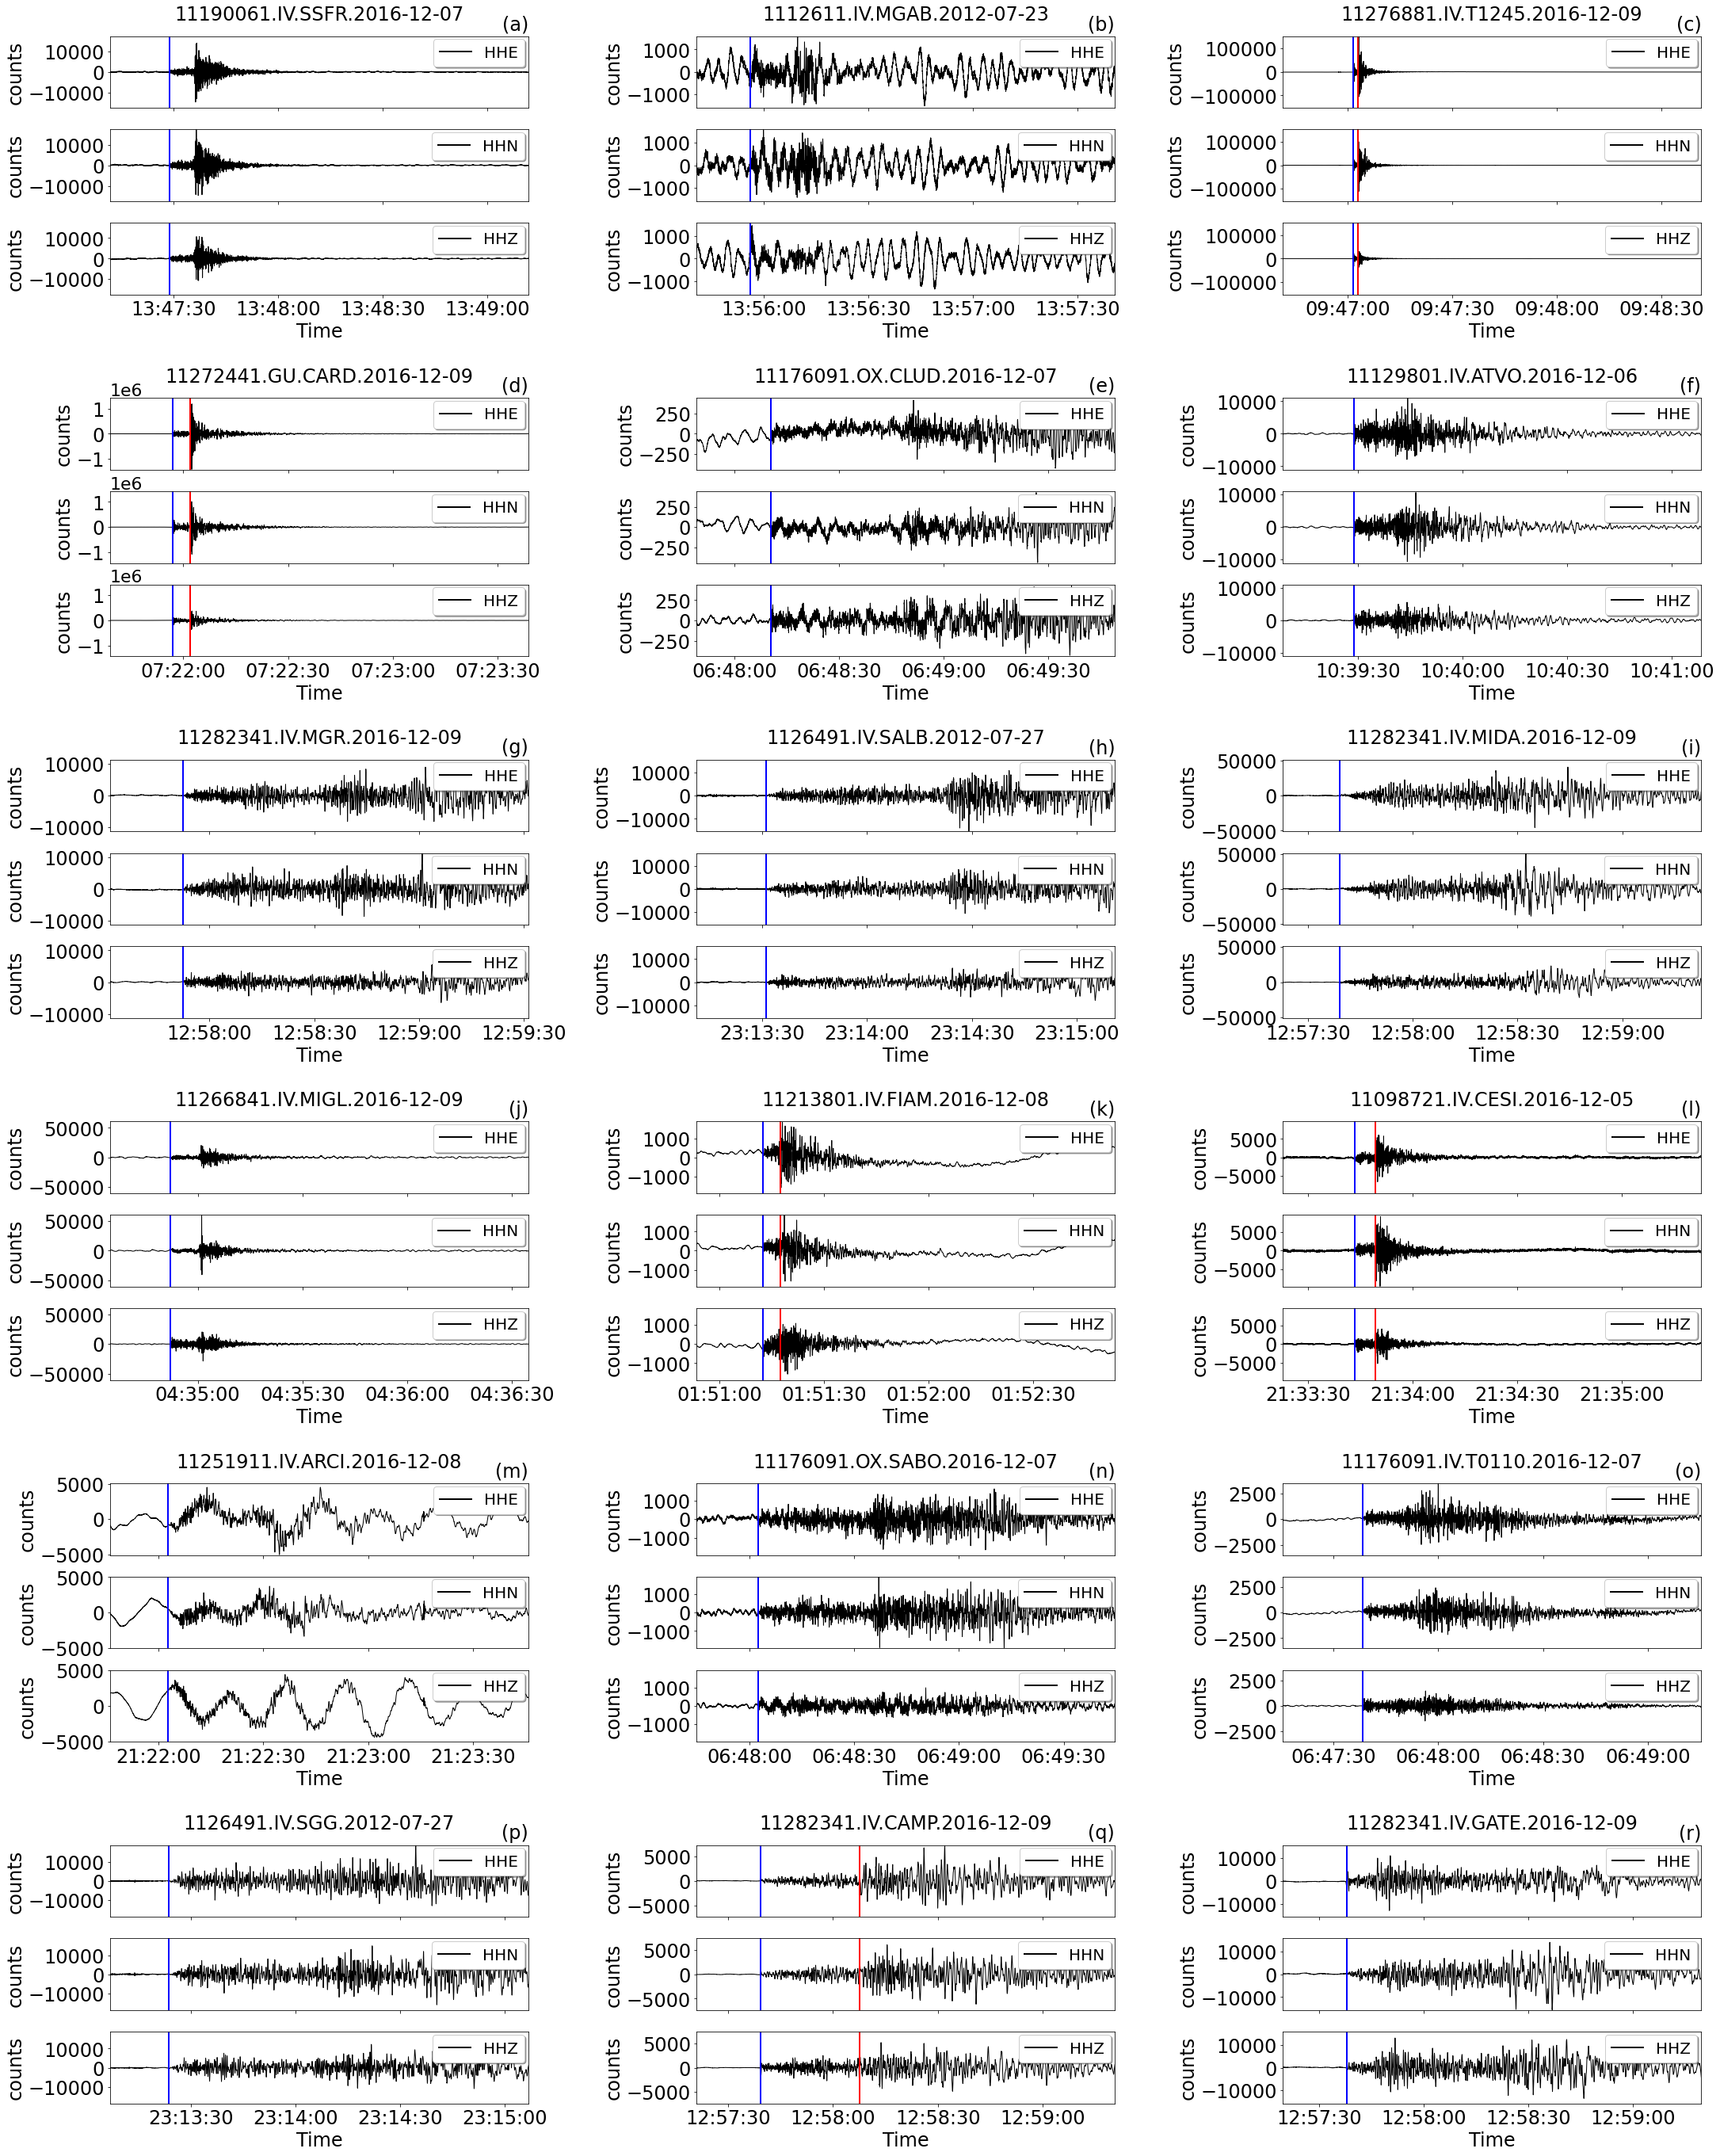

In [24]:
lines = chosen_lines
# Kind of unit
units = len(lines)*["counts"]

# Do you want the traces filtered?
filt = False
freq_min=3.0
freq_max=20.0

nrow=int(len(lines)/plots_line)
ncol=plots_line

labs = alllabs[:(ncol*nrow)]

wftype='ev_c'
if wftype == 'ev_c':
    df = events_metaData
    h5 = events_h5File
elif wftype == 'ev_gm':
    df = events_metaData
    h5 = gm_h5File
elif wftype == 'noise':
    df = noise_metaData
    h5 = noise_h5File

multiple_streams(df,h5,lines,wftype,nrow,ncol,units,labs,filt,freq_min,freq_max)
gm_figname=os.path.join(FIGDIR,'Fig_14.png')
plt.savefig(gm_figname,dpi=300)



# Select waveforms for Figure 15
Example of randomly selected problematic earthquake waveforms of the broadband HH channels. Each row contains threerandomly selected traces drawn according to the following criteria: (a-c) traces with `trace_GPD_[P,S]_number` > 3 (7.96 % of thetotal of the HH channels); (d-f) traces with `trace_EQT_number_detections` > 3 (0.38 % of the total of the HH channels); (g-i) traces `trace_[ENZ]_snr_db` with at least one component in the 10% quantile (18.10 % of the total of the HH channels); (j-l) traces with all `trace_[ENZ]_median_counts` either in the first 10% or the last 10% quantiles (5.90 % of the total of the HH channels); (m-o) traces with `trace_[ENZ]_median_counts` either in the first 10% or the last 10% quantiles and corresponding `trace_[ENZ]_snr_db` excluded from the first quartile (5.06 % HH dataset). The arrival times of P- and S-wave onsets are shown by blue and red vertical lines,respectively.

In [25]:
cha = 'HH'

In [26]:
# TOTAL = events_metaData.shape[0]
TOTAL = events_metaData.loc[events_metaData.station_channels == cha].shape[0]
TOTAL

3893

### Define selection criteria based on metadata statistics

In [27]:
df_tmp = events_metaData.loc[(events_metaData.station_channels == cha)]
percents = [0.1, 0.25, 0.75, 0.9]
df_tmp[['trace_E_median_counts','trace_N_median_counts','trace_Z_median_counts',
        'trace_E_snr_db','trace_N_snr_db','trace_Z_snr_db' ,
        'trace_E_rms_counts', 'trace_N_rms_counts','trace_Z_rms_counts']].describe(percentiles=percents)

,trace_E_median_counts,trace_N_median_counts,trace_Z_median_counts,trace_E_snr_db,trace_N_snr_db,trace_Z_snr_db,trace_E_rms_counts,trace_N_rms_counts,trace_Z_rms_counts
count,3893.000000,3893.000000,3893.000000,3886.000000,3886.000000,3886.000000,3893.000000,3893.000000,3.893000e+03
mean,26.008862,7.812741,68.759954,20.119065,20.280529,18.125744,2746.800319,2773.775523,2.051061e+03
std,1669.505451,760.585669,4398.266715,14.071459,13.959102,13.420478,12530.073958,9827.570266,2.517532e+04
min,-6622.000000,-13263.000000,-10247.500000,-13.440470,-13.249896,-13.879028,17.814718,15.978491,1.653521e+01
10%,-32.000000,-32.000000,-12.000000,3.309558,3.491138,2.583829,102.565152,101.953430,5.877876e+01
25%,-7.000000,-8.000000,-2.000000,9.337772,9.376121,7.658003,203.568631,205.588313,1.297846e+02
50%,0.000000,0.000000,0.000000,18.120288,18.608185,16.216453,517.637210,529.269350,3.177163e+02
75%,7.000000,8.000000,3.000000,29.238424,29.569234,26.501679,1627.774097,1634.950136,9.819552e+02
90%,32.000000,34.000000,12.000000,39.694378,39.754478,36.505801,5213.680651,5177.258972,3.197054e+03
max,102677.500000,37610.500000,273372.000000,74.336617,73.574390,68.742970,583182.284666,246606.517802,1.535769e+06


In [28]:
chosen_lines = []
plots_line = 3

#### 1) select earthquakes with `trace_GPD_[P,S]_number` > 3 and `station_channels` = 'HH'

In [29]:
df_tmp = events_metaData.loc[((events_metaData.trace_GPD_P_number > 3) | (events_metaData.trace_GPD_S_number > 3)) & 
                    (events_metaData.station_channels == cha)]
#
ntot = df_tmp.shape[0]
print ("N records: ", ntot, "% total: ", float(ntot/TOTAL * 100.))
#
if ntot > 0:
    lista = list(df_tmp.sample(n=plots_line, random_state=1).index)
    chosen_lines = chosen_lines + lista
    chosen_lines
else:
    print('no waveform found')

N records:  1291 % total:  33.1620857950167


#### 2) select earthquakes with `trace_EQT_number_detections` > 3 and `station_channels` = 'HH'

In [30]:
df_tmp = events_metaData.loc[(events_metaData.trace_EQT_number_detections > 3) & 
                    (events_metaData.station_channels == cha)]
#
ntot = df_tmp.shape[0]
print ("N records: ", ntot, "% total: ", float(ntot/TOTAL * 100.))
#
if ntot > 0:
    lista = list(df_tmp.sample(n=plots_line, random_state=1).index)
    chosen_lines = chosen_lines + lista
    chosen_lines
else:
    print('no waveform found')

N records:  51 % total:  1.3100436681222707


#### 3) select earthquakes with at least one component `trace_[ENZ]_snr_db` in the 10% quantile and `station_channels` = 'HH'

In [31]:
snrv_E, snrv_N, snrv_Z = (2.313, 2.297, 1.2118)
df_tmp = events_metaData.loc[((events_metaData.trace_E_snr_db < snrv_E)| (events_metaData.trace_N_snr_db < snrv_N) | (events_metaData.trace_Z_snr_db < snrv_Z))
                      & (events_metaData.station_channels == cha)]
#
ntot = df_tmp.shape[0]
print ("N records: ", ntot, "% total: ", float(ntot/TOTAL * 100.))
#
if ntot > 0:
    lista = list(df_tmp.sample(n=plots_line, random_state=1).index)
    chosen_lines = chosen_lines + lista
    chosen_lines
else:
    print('no waveform found')

N records:  542 % total:  13.922424865142563


#### 4) select earthquakes with `trace_[ENZ]_median_counts` in the 10% or 90% quantile and `station_channels` = 'HH'

In [32]:
min_threv_E, min_threv_N, min_threv_Z = (-22.0, -22.0, -11.5)
max_threv_E, max_threv_N, max_threv_Z = (22.0, 22.5, 12.0)

df_tmp = events_metaData.loc[(((events_metaData.trace_E_median_counts < min_threv_E) | (events_metaData.trace_E_median_counts > max_threv_E)) & 
                    ((events_metaData.trace_N_median_counts < min_threv_N) | (events_metaData.trace_N_median_counts > max_threv_N)) &
                    ((events_metaData.trace_Z_median_counts < min_threv_Z) | (events_metaData.trace_Z_median_counts > max_threv_Z)))  & 
                      (events_metaData.station_channels == cha)]
#
ntot = df_tmp.shape[0]
print ("N records: ", ntot, "% total: ", float(ntot/TOTAL * 100.))
#
if ntot > 0:
    lista = list(df_tmp.sample(n=plots_line, random_state=1).index)
    chosen_lines = chosen_lines + lista
    chosen_lines
else:
    print('no waveform found')

N records:  357 % total:  9.170305676855897


#### 5) select  earthquake  with `trace_[ENZ]_median_counts` in the first and last 10%, `trace_[ENZ]_snr_db` above 25% and `station_channels` = 'HH'

In [33]:
# 10%
min_threv_E, min_threv_N, min_threv_Z = (-22.0, -22.0, -11.5)
max_threv_E, max_threv_N, max_threv_Z = (22.0, 22.5, 12.0)

# 25%
snrv_E, snrv_N, snrv_Z = (7.29, 7.273, 5.506)

df_tmp = events_metaData.loc[(((events_metaData.trace_E_median_counts < min_threv_E) | (events_metaData.trace_E_median_counts > max_threv_E)) & 
                    ((events_metaData.trace_N_median_counts < min_threv_N) | (events_metaData.trace_N_median_counts > max_threv_N)) &
                    ((events_metaData.trace_Z_median_counts < min_threv_Z) | (events_metaData.trace_Z_median_counts > max_threv_Z)))  &
                    ((events_metaData.trace_E_snr_db > snrv_E) | (events_metaData.trace_N_snr_db > snrv_N) | (events_metaData.trace_Z_snr_db > snrv_Z)) &
                      (events_metaData.station_channels == cha)]
#
ntot = df_tmp.shape[0]
print ("N records: ", ntot, "% total: ", float(ntot/TOTAL * 100.))
#
if ntot > 0:
    lista = list(df_tmp.sample(n=plots_line, random_state=1).index)
    chosen_lines = chosen_lines + lista
    chosen_lines
else:
    print('no waveform found')

N records:  299 % total:  7.680452093501156


## Plot waveforms in Counts

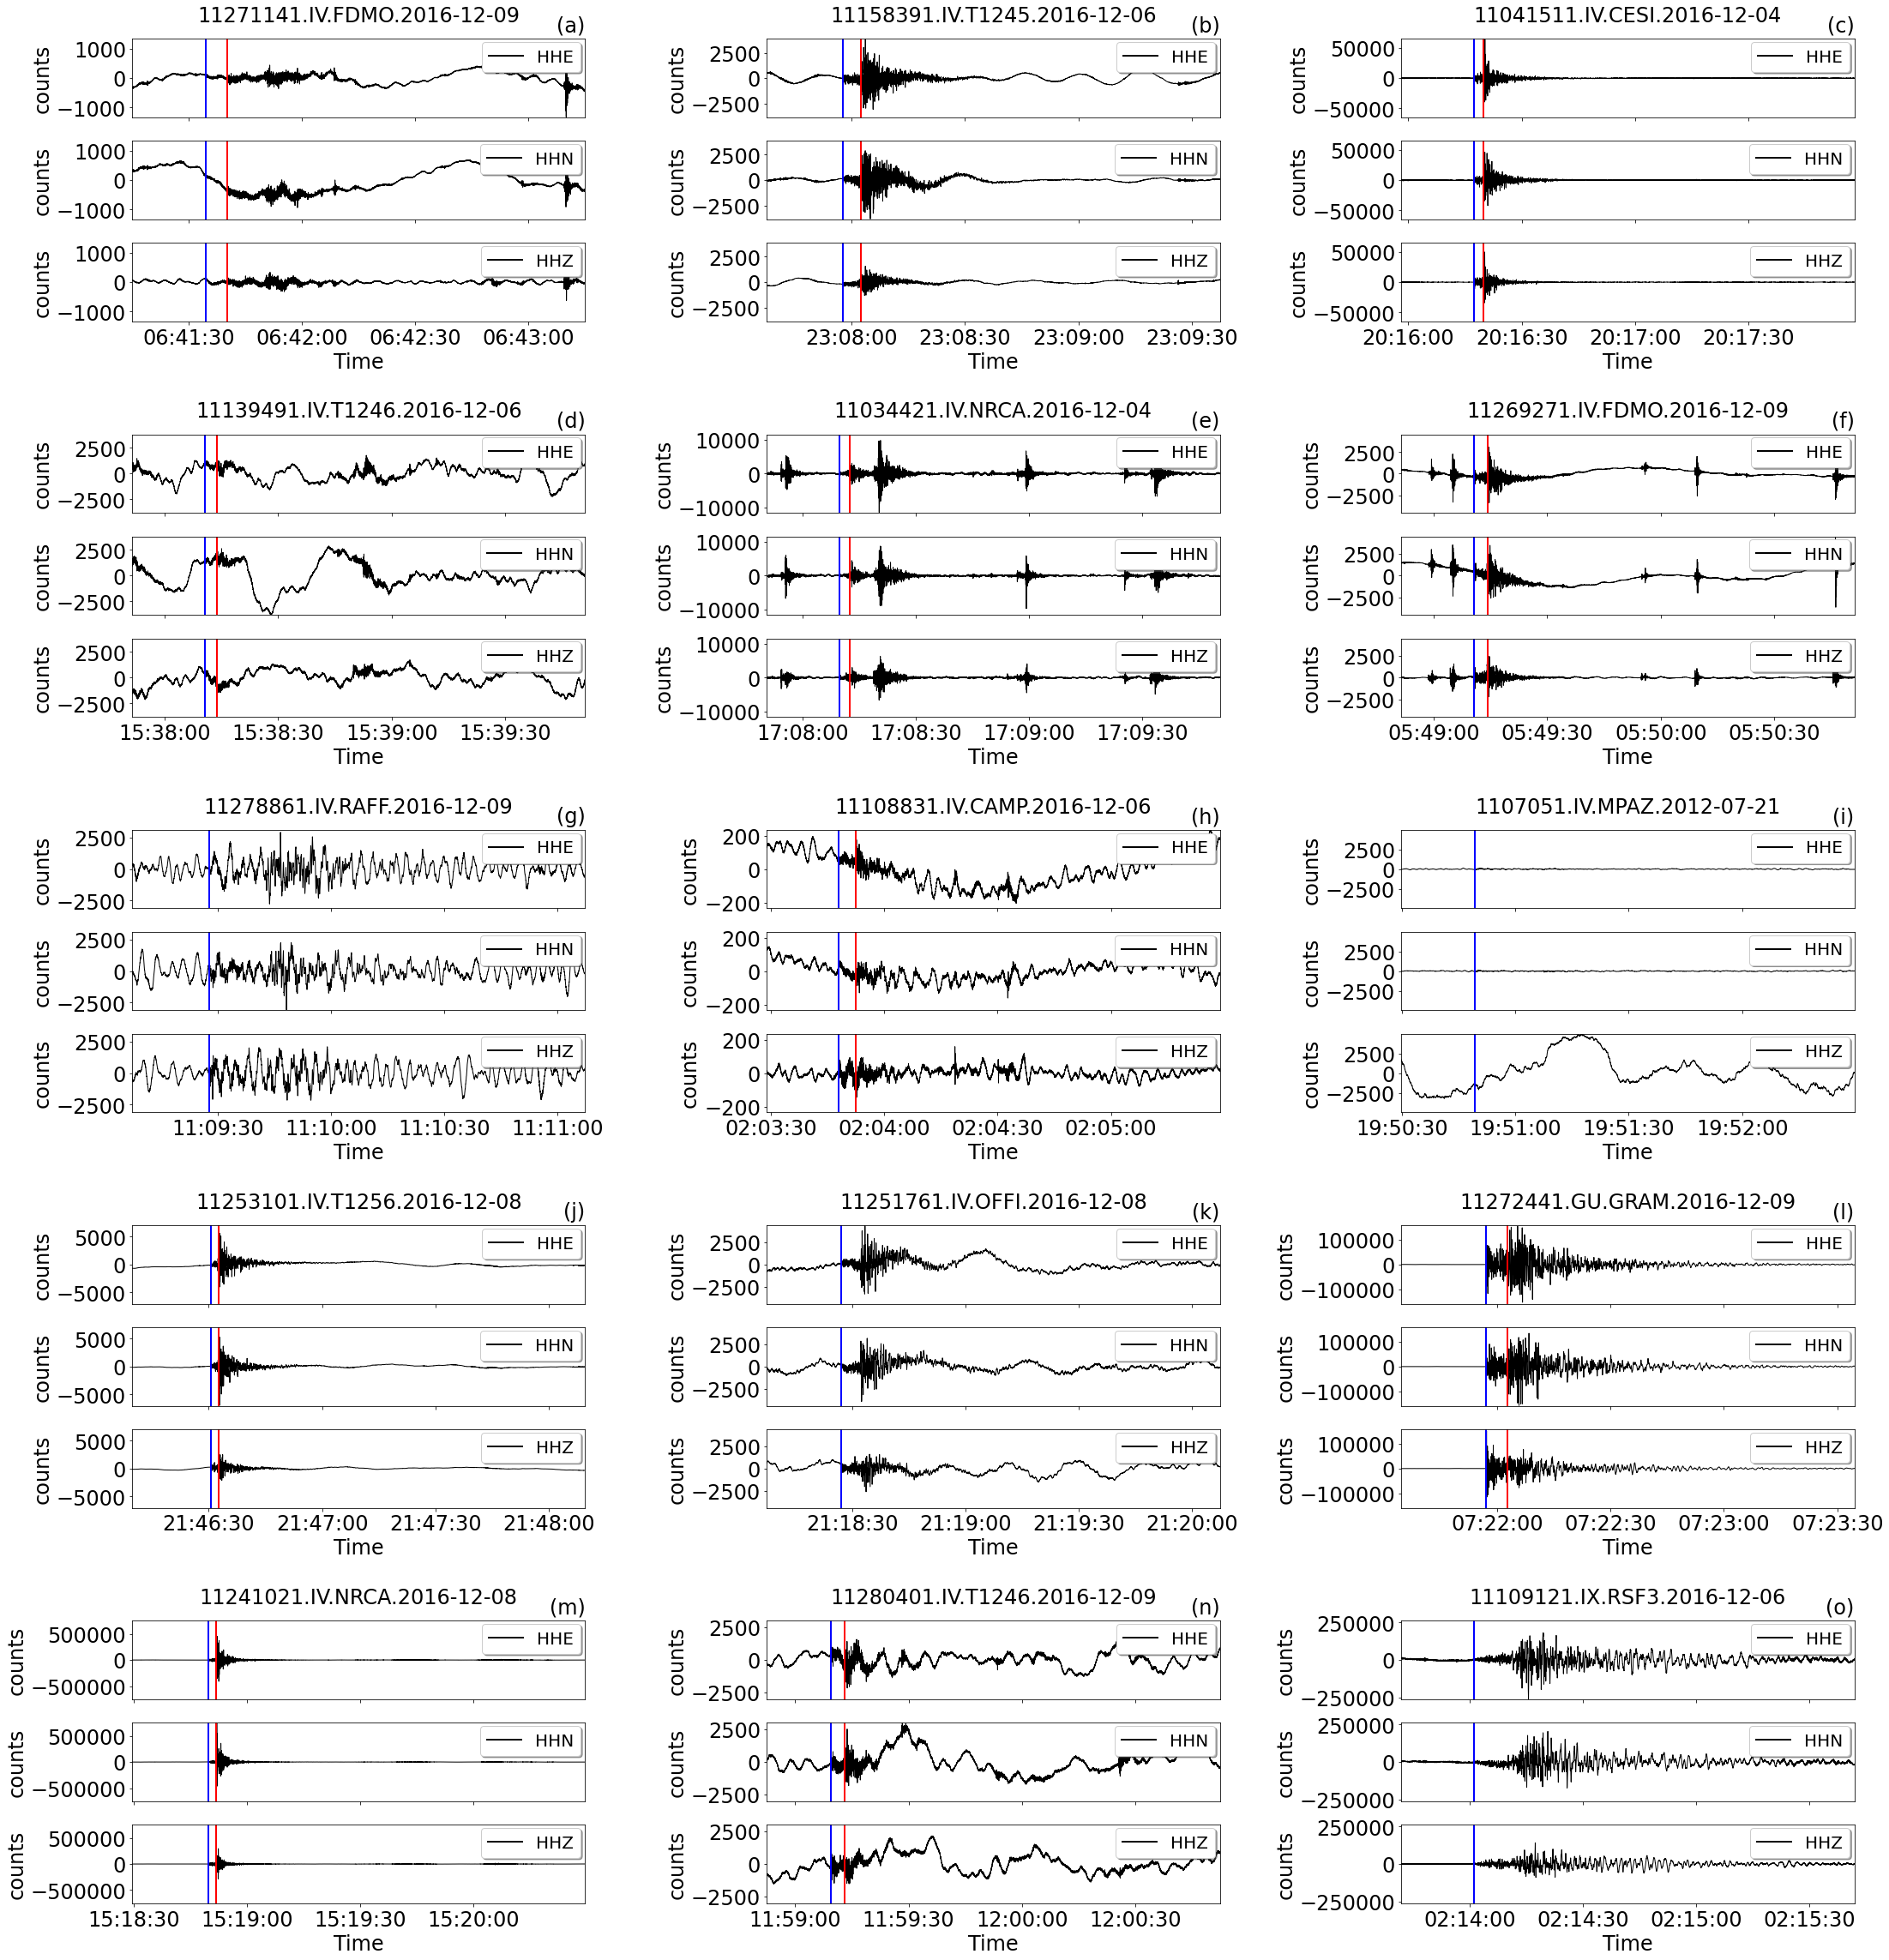

In [34]:
lines = chosen_lines
# Kind of unit
units = len(lines)*["counts"]

# Do you want the traces filtered?
filt = False
freq_min=3.0
freq_max=20.0

nrow=int(len(lines)/plots_line)
ncol=plots_line

labs = alllabs[:(ncol*nrow)]
wftype = 'ev_c'
if wftype == 'ev_c':
    df = events_metaData
    h5 = events_h5File
elif wftype == 'ev_gm':
    df = events_metaData
    h5 = gm_h5File
elif wftype == 'noise':
    df = noise_metaData
    h5 = noise_h5File


multiple_streams(df,h5,lines,wftype,nrow,ncol,units,labs,filt,freq_min,freq_max)

gm_figname=os.path.join(FIGDIR,'Fig_15.png')
plt.savefig(gm_figname,dpi=300)



# Select waveforms for Figure 16
Example of randomly selected event waveforms in ground motion units of the HH, EH and HN channels in INSTANCE. The traces are representative of 75% of the data and belonging to the second, third and fourth quartiles of each channel. Each row contains three randomly selected traces drawn as follows: (a-f) HH traces with `trace_pga_perc`>5.1e-4 % g; (g-l) EH traces with `trace_pga_perc`>9.3e-4 % g; (m-r) HN traces with `trace_pga_perc`>8.7e-4 % g; The arrival times of P- and S-wave onsets are shown by blue andred vertical lines, respectively

## Select based on PGA  in the 75% of data (i.e., from 25% to 100%)

### 1) HH channels

In [35]:
cha = 'HH'
df_tmp = events_metaData[(events_metaData['station_channels'].isin([cha]))]

In [36]:
TOTAL = df_tmp.shape[0]
TOTAL

3893

In [37]:
# 25%
pgav = 5.1e-4

In [38]:
chosen_lines = []
plots_line = 3

In [39]:
neqs = 6
df_tmp = events_metaData.loc[ (events_metaData.trace_pga_perc > pgav) &
                    (events_metaData.station_channels == cha)]

ntot = df_tmp.shape[0]
print ("N records: ", ntot, "% total: ", float(ntot/TOTAL * 100.))
#
if ntot > 0:
    lista = list(df_tmp.sample(n=neqs, random_state=1).index)
    chosen_lines = chosen_lines + lista
    chosen_lines
else:
    print('no waveform found')

N records:  3257 % total:  83.66298484459286


### 2) EH channels

In [40]:
cha = 'EH'
df_tmp = events_metaData[(events_metaData['station_channels'].isin([cha]))]

In [41]:
TOTAL = df_tmp.shape[0]
TOTAL

2517

In [42]:
# 25%
pgav = 9.3e-4

In [43]:
#
neqs = 6
df_tmp = events_metaData.loc[ (events_metaData.trace_pga_perc > pgav) &
                    (events_metaData.station_channels == cha)]

ntot = df_tmp.shape[0]
print ("N records: ", ntot, "% total: ", float(ntot/TOTAL * 100.))
#
if ntot > 0:
    lista = list(df_tmp.sample(n=neqs, random_state=1).index)
    chosen_lines = chosen_lines + lista
    chosen_lines
else:
    print('no waveform found')

N records:  2132 % total:  84.70401271354787


### 3) HN channels

In [44]:
cha = 'HN'
df_tmp = events_metaData[(events_metaData['station_channels'].isin([cha]))]


In [45]:
TOTAL = df_tmp.shape[0]
TOTAL

3550

In [46]:
# 25%
pgav = 8.7e-4

In [47]:
#
neqs = 6
df_tmp = events_metaData.loc[(events_metaData.trace_pga_perc > pgav) & 
                            (events_metaData.station_channels == cha)]

ntot = df_tmp.shape[0]
print ("N records: ", ntot, "% total: ", float(ntot/TOTAL * 100.))
#
if ntot > 0:
    lista = list(df_tmp.sample(n=neqs, random_state=1).index)
    chosen_lines = chosen_lines + lista
    chosen_lines
else:
    print('no waveform found')

N records:  3077 % total:  86.67605633802818


# PLOT EVENTS IN GROUND MOTION UNITS

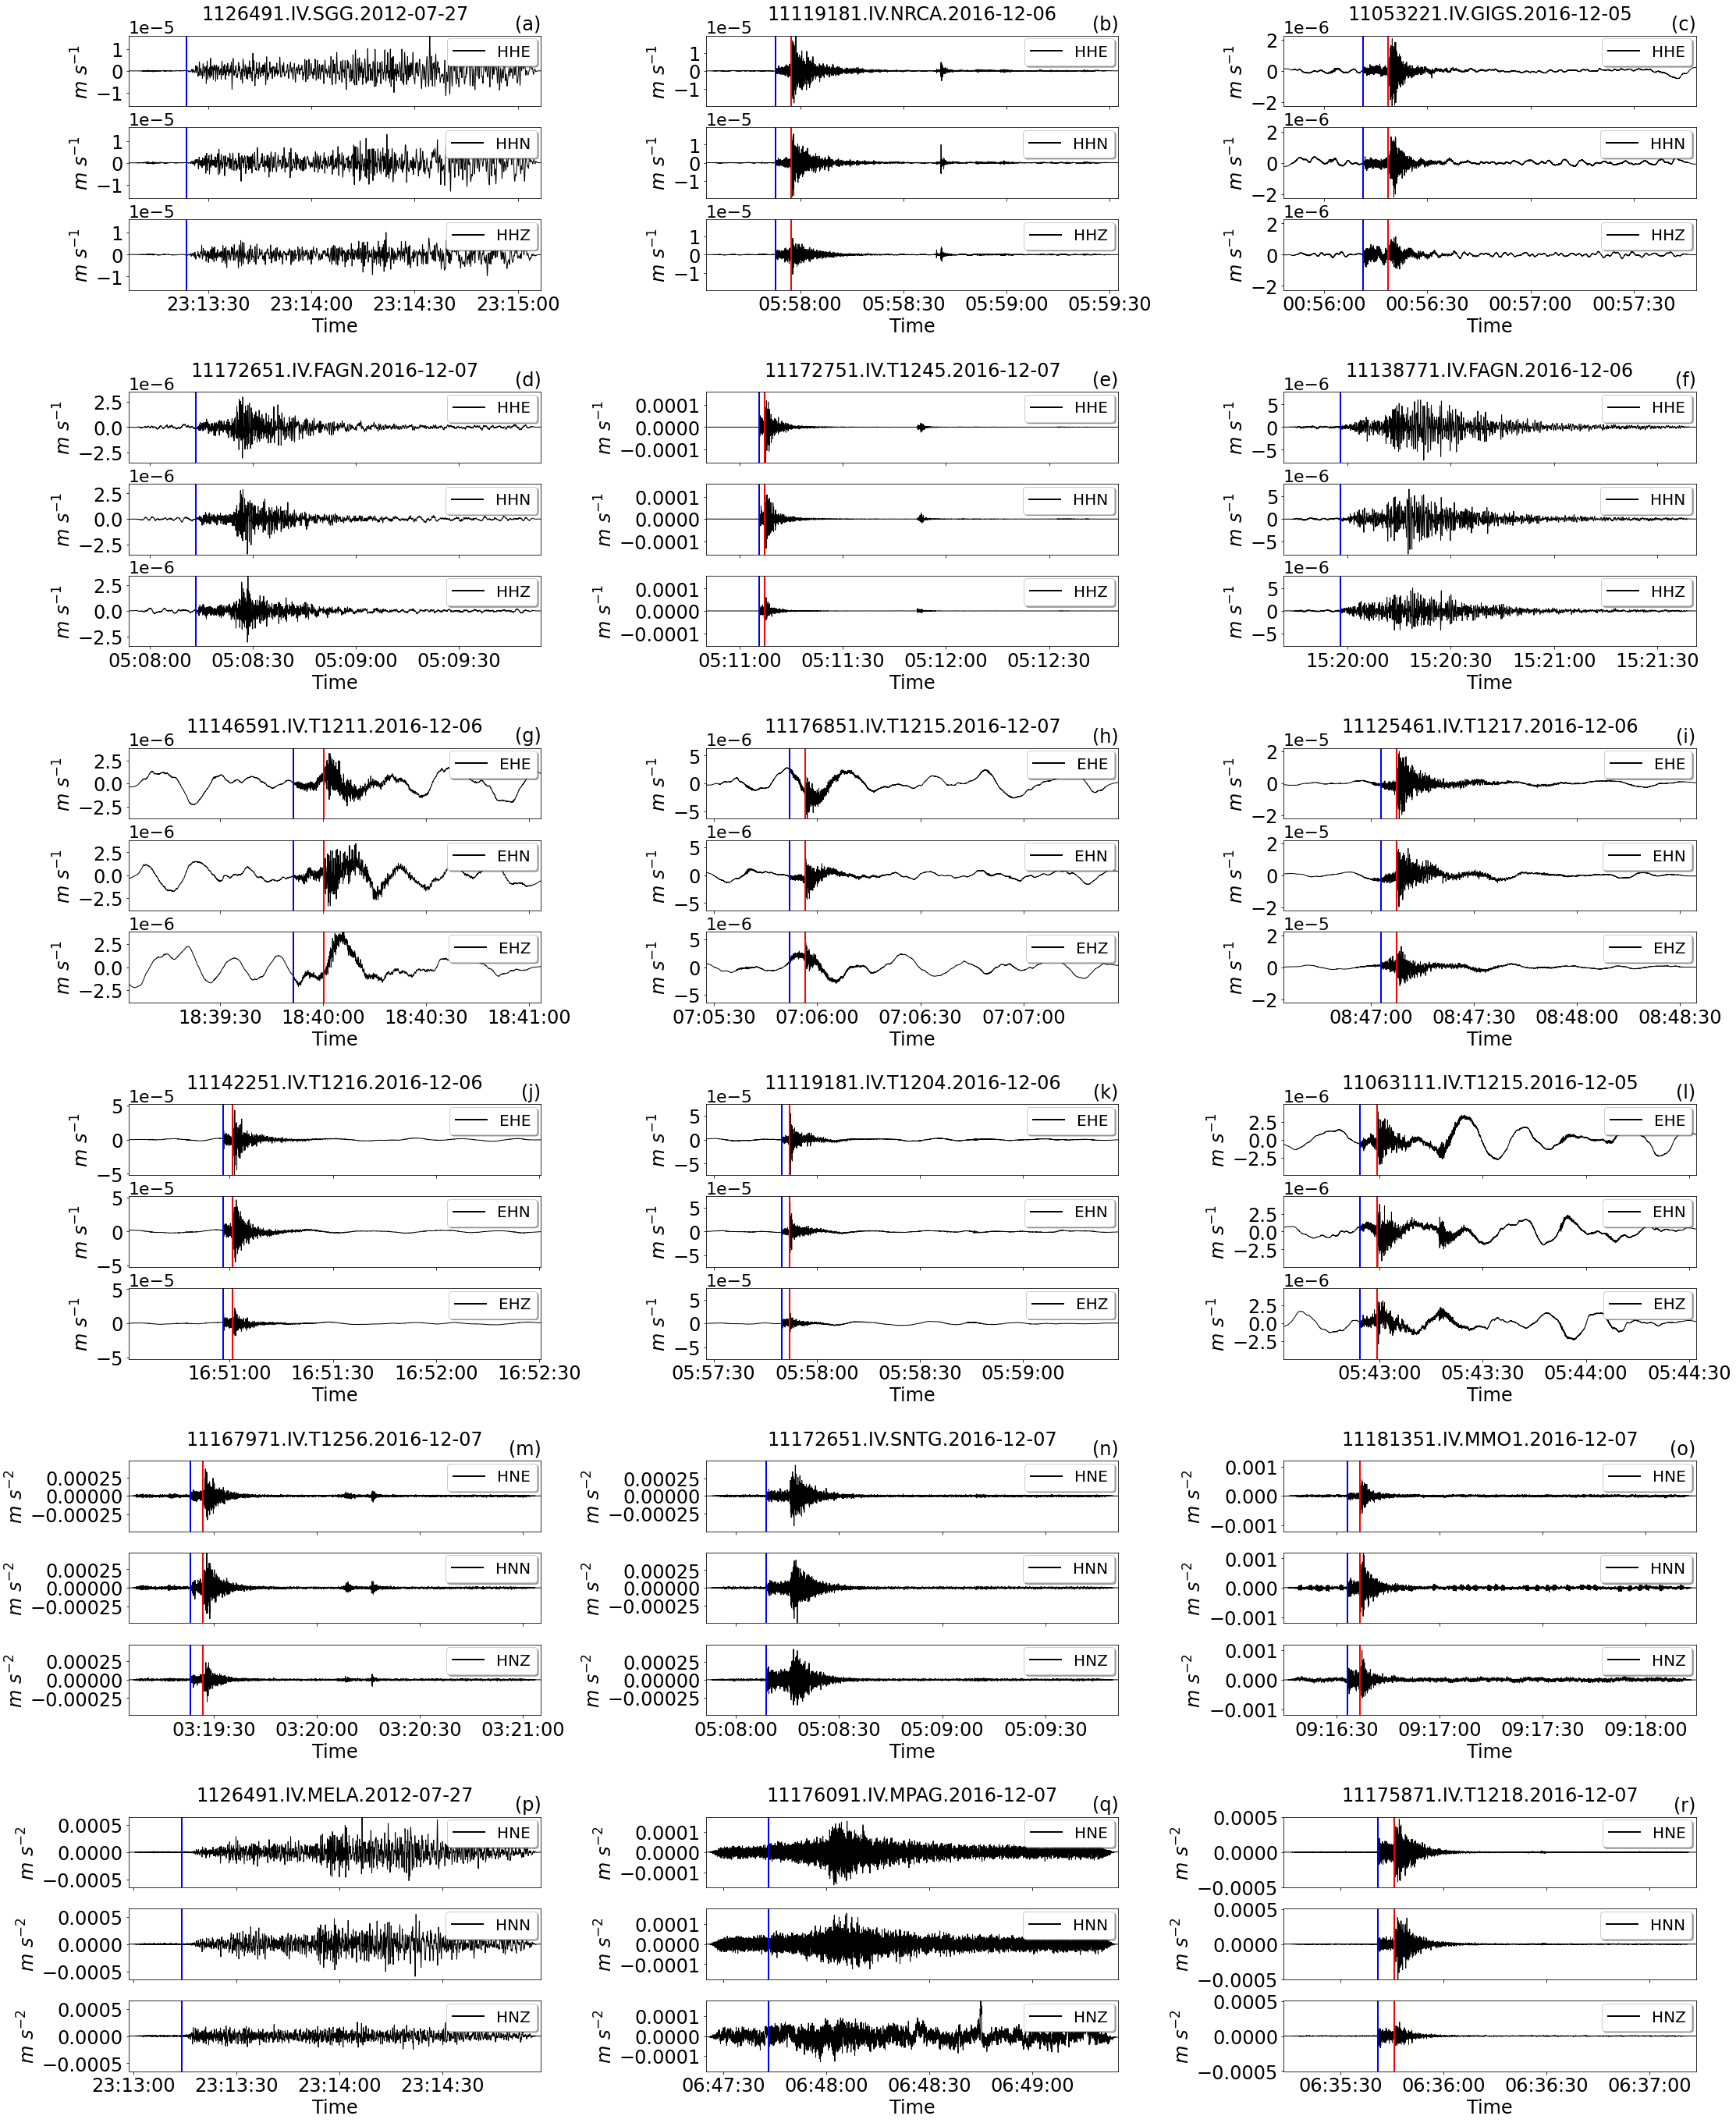

In [48]:
lines = chosen_lines
# Kind of unit
# units = len(lines)*["$m~s^{-1}$"]
units = ["$m~s^{-1}$","$m~s^{-1}$","$m~s^{-1}$","$m~s^{-1}$","$m~s^{-1}$","$m~s^{-1}$",
         "$m~s^{-1}$","$m~s^{-1}$","$m~s^{-1}$","$m~s^{-1}$","$m~s^{-1}$","$m~s^{-1}$",
         "$m~s^{-2}$","$m~s^{-2}$","$m~s^{-2}$","$m~s^{-2}$","$m~s^{-2}$","$m~s^{-2}$"]

# Do you want the traces filtered?
filt = False
freq_min=3.0
freq_max=20.0

nrow=int(len(lines)/plots_line)

ncol=plots_line
labs = alllabs[:(ncol*nrow)]

wftype = 'ev_gm'
if wftype == 'ev_c':
    df = events_metaData
    h5 = events_h5File
elif wftype == 'ev_gm':
    df = events_metaData
    h5 = gm_h5File
elif wftype == 'noise':
    df = noise_metaData
    h5 = noise_h5File


multiple_streams(df,h5,lines,wftype,nrow,ncol,units,labs,filt,freq_min,freq_max)

figname=os.path.join(FIGDIR,'Fig_16.png')
plt.savefig(figname,dpi=300)



# Select noise waveform for Figure 20
Example   of   randomly   selected   noise   waveforms   of   the   HH   and   EH   channels   contained   in   INSTANCE.   Each row   contains   three   randomly   selected   traces   drawn   according   to   the   following   criteria:   (a-c) `trace_GPD_[P,S]_number`>3   (11.6   %   of   the   total   of   the   EH   channels);   (d-f) `trace_EQT_number_detections`>3   (0.13   %   of   the   total   ofthe  EH  channels);  (g-i)  all  the `trace_[E,N,Z]_rms_counts`<[1013,1071,793]  (86.31  %  of  the  total  of  the  HH  chan-nels);  (j-l)  any  of  the `trace_[E,N,Z]_rms_counts`>[1013,1071,793]  (13.69  %  of  the  total  of  the  HH  channels);  (m-o)  all  the `trace_[E,N,Z]_rms_counts`<[327.1,332,307]  (86.36  %  of  the  total  of  the  EH  channels);  (p-r)  any  of  the `trace_[E,N,Z]_rms_counts`>[327.1,332,307] (13.64 % of the total of the EH channels)

In [49]:
cha = "HH"

In [50]:
TOTAL = noise_metaData.loc[noise_metaData.station_channels == cha].shape[0]
TOTAL

501

### Define selection criteria based on metadata statistics

In [51]:
df_tmp = noise_metaData.loc[(noise_metaData.station_channels == cha)]
percents = [0.1, 0.25, 0.75, 0.9]
df_tmp[['trace_E_median_counts','trace_N_median_counts','trace_Z_median_counts',
        'trace_E_rms_counts', 'trace_N_rms_counts','trace_Z_rms_counts']].describe(percentiles=percents)

,trace_E_median_counts,trace_N_median_counts,trace_Z_median_counts,trace_E_rms_counts,trace_N_rms_counts,trace_Z_rms_counts
count,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000
mean,1.233533,9.820359,549.668663,474.108146,505.995068,2026.402541
std,43.465634,200.572734,12254.343532,1223.333859,1155.866899,36729.475367
min,-495.000000,-208.500000,-456.000000,2.431000,2.957000,2.179000
10%,-11.000000,-13.000000,-9.000000,49.579000,51.826000,44.461000
25%,-3.000000,-4.000000,-2.000000,92.515000,91.077000,85.696000
50%,0.000000,0.000000,0.000000,201.594000,204.455000,168.966000
75%,5.000000,3.000000,3.000000,423.216000,454.735000,373.393000
90%,16.000000,16.500000,10.000000,916.931000,1004.464000,807.387000
max,570.000000,4430.000000,274289.000000,18870.138000,13017.285000,822262.349000


In [52]:
cha='EH'

In [53]:
df_tmp = noise_metaData.loc[(noise_metaData.station_channels == cha)]
percents = [0.1, 0.25, 0.75, 0.9]
df_tmp[['trace_E_median_counts','trace_N_median_counts','trace_Z_median_counts',
        'trace_E_rms_counts', 'trace_N_rms_counts','trace_Z_rms_counts']].describe(percentiles=percents)

,trace_E_median_counts,trace_N_median_counts,trace_Z_median_counts,trace_E_rms_counts,trace_N_rms_counts,trace_Z_rms_counts
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,-5.787179,-4.138462,-4.961538,1193.143385,211.611272,251.400928
std,73.024460,45.213939,61.231749,13525.213495,610.877316,1006.670740
min,-1015.500000,-603.000000,-830.500000,0.564000,0.674000,0.643000
10%,-2.000000,-2.800000,-2.000000,9.577200,10.046200,6.364200
25%,0.000000,0.000000,0.000000,23.651500,22.826500,19.868000
50%,0.000000,0.000000,0.000000,59.057000,61.897000,51.160000
75%,0.000000,0.000000,0.000000,147.093500,153.687500,136.511500
90%,2.000000,3.000000,2.000000,342.204000,364.534800,370.960600
max,27.000000,35.000000,33.500000,188641.258000,6794.395000,9699.623000


In [54]:
TOTAL = noise_metaData.loc[noise_metaData.station_channels == cha].shape[0]
TOTAL

195

In [55]:
chosen_lines = []
plots_line = 3

#### 1) `trace_GPD_[PS]_number` > 3 & `station_channels` = 'EH'

In [56]:
df_tmp = noise_metaData.loc[((noise_metaData.trace_GPD_P_number > 3) | (noise_metaData.trace_GPD_S_number > 3)) &
                   (noise_metaData.station_channels == cha)]

ntot = df_tmp.shape[0]
print ("N records: ", ntot, "% total: ", float(ntot/TOTAL * 100.))
#
if ntot > 0:
    lista = list(df_tmp.sample(n=plots_line, random_state=1).index)
    chosen_lines = chosen_lines + lista
    chosen_lines
else:
    print('no waveform found')

N records:  23 % total:  11.794871794871794


#### 2) `trace_EQT_number_detection` > 3 & `station_channels` = 'EH'

In [57]:
df_tmp = noise_metaData.loc[(noise_metaData.trace_EQT_number_detections > 3) & 
                   (noise_metaData.station_channels == cha)]

ntot = df_tmp.shape[0]
print ("N records: ", ntot, "% total: ", float(ntot/TOTAL * 100.))
#
if ntot > 0:
    lista = list(df_tmp.sample(n=plots_line, random_state=1).index)
    chosen_lines = chosen_lines + lista
    chosen_lines
else:
    print('no waveform found')

N records:  0 % total:  0.0
no waveform found


#### 3) `trace_[E,N,Z]_rms_counts`<[1013,1071,793] & `station_channels` = 'HH'

In [58]:
cha = 'HH'
TOTAL = noise_metaData.loc[noise_metaData.station_channels == cha].shape[0]
TOTAL

501

In [59]:
min_E_rms = 1013
min_N_rms = 1071
min_Z_rms = 793

df_tmp = noise_metaData.loc[((noise_metaData.trace_E_rms_counts <  min_E_rms) & 
                             (noise_metaData.trace_N_rms_counts <  min_N_rms) &
                             (noise_metaData.trace_Z_rms_counts <  min_Z_rms)) &
                             (noise_metaData.station_channels == cha)]

ntot = df_tmp.shape[0]
print ("N records: ", ntot, "% total: ", float(ntot/TOTAL * 100.))
#
if ntot > 0:
    lista = list(df_tmp.sample(n=plots_line, random_state=1).index)
    chosen_lines = chosen_lines + lista
    chosen_lines
else:
    print('no waveform found')

N records:  437 % total:  87.2255489021956


#### 4) at least one of `trace_[E,N,Z]_rms_counts`>[1013,1071,793] & `station_channels` = 'HH'

In [60]:
df_tmp = noise_metaData.loc[((noise_metaData.trace_E_rms_counts >  min_E_rms) | 
                             (noise_metaData.trace_N_rms_counts >  min_N_rms) |
                             (noise_metaData.trace_Z_rms_counts >  min_Z_rms)) &
                             (noise_metaData.station_channels == cha)]

ntot = df_tmp.shape[0]
print ("N records: ", ntot, "% total: ", float(ntot/TOTAL * 100.))
#
if ntot > 0:
    lista = list(df_tmp.sample(n=plots_line, random_state=1).index)
    chosen_lines = chosen_lines + lista
    chosen_lines
else:
    print('no waveform found')

N records:  64 % total:  12.77445109780439


Selectes # 25221

#### 5) all `trace_[E,N,Z]_rms_counts`<[327.1,332,307] & `station_channels` = 'EH'

In [61]:
cha = 'EH'
TOTAL = noise_metaData.loc[noise_metaData.station_channels == cha].shape[0]
TOTAL

195

In [62]:
min_E_rms = 327.1
min_N_rms = 332
min_Z_rms = 307
df_tmp = noise_metaData.loc[((noise_metaData.trace_E_rms_counts <  min_E_rms) & 
                             (noise_metaData.trace_N_rms_counts <  min_N_rms) &
                             (noise_metaData.trace_Z_rms_counts <  min_Z_rms)) &
                             (noise_metaData.station_channels == cha)]

ntot = df_tmp.shape[0]
print ("N records: ", ntot, "% total: ", float(ntot/TOTAL * 100.))
#
if ntot > 0:
    lista = list(df_tmp.sample(n=plots_line, random_state=1).index)
    chosen_lines = chosen_lines + lista
    chosen_lines
else:
    print('no waveform found')

N records:  165 % total:  84.61538461538461


#### 6) at least one og the `trace_[E,N,Z]_rms_counts`<[327.1,332,307] & `station_channels` = 'EH'

In [63]:
df_tmp = noise_metaData.loc[((noise_metaData.trace_E_rms_counts >  min_E_rms) | 
                             (noise_metaData.trace_N_rms_counts >  min_N_rms) |
                             (noise_metaData.trace_Z_rms_counts >  min_Z_rms)) &
                             (noise_metaData.station_channels == cha)]

ntot = df_tmp.shape[0]
print ("N records: ", ntot, "% total: ", float(ntot/TOTAL * 100.))
#
if ntot > 0:
    lista = list(df_tmp.sample(n=plots_line, random_state=1).index)
    chosen_lines = chosen_lines + lista
    chosen_lines
else:
    print('no waveform found')

N records:  30 % total:  15.384615384615385


# PLOT NOISE

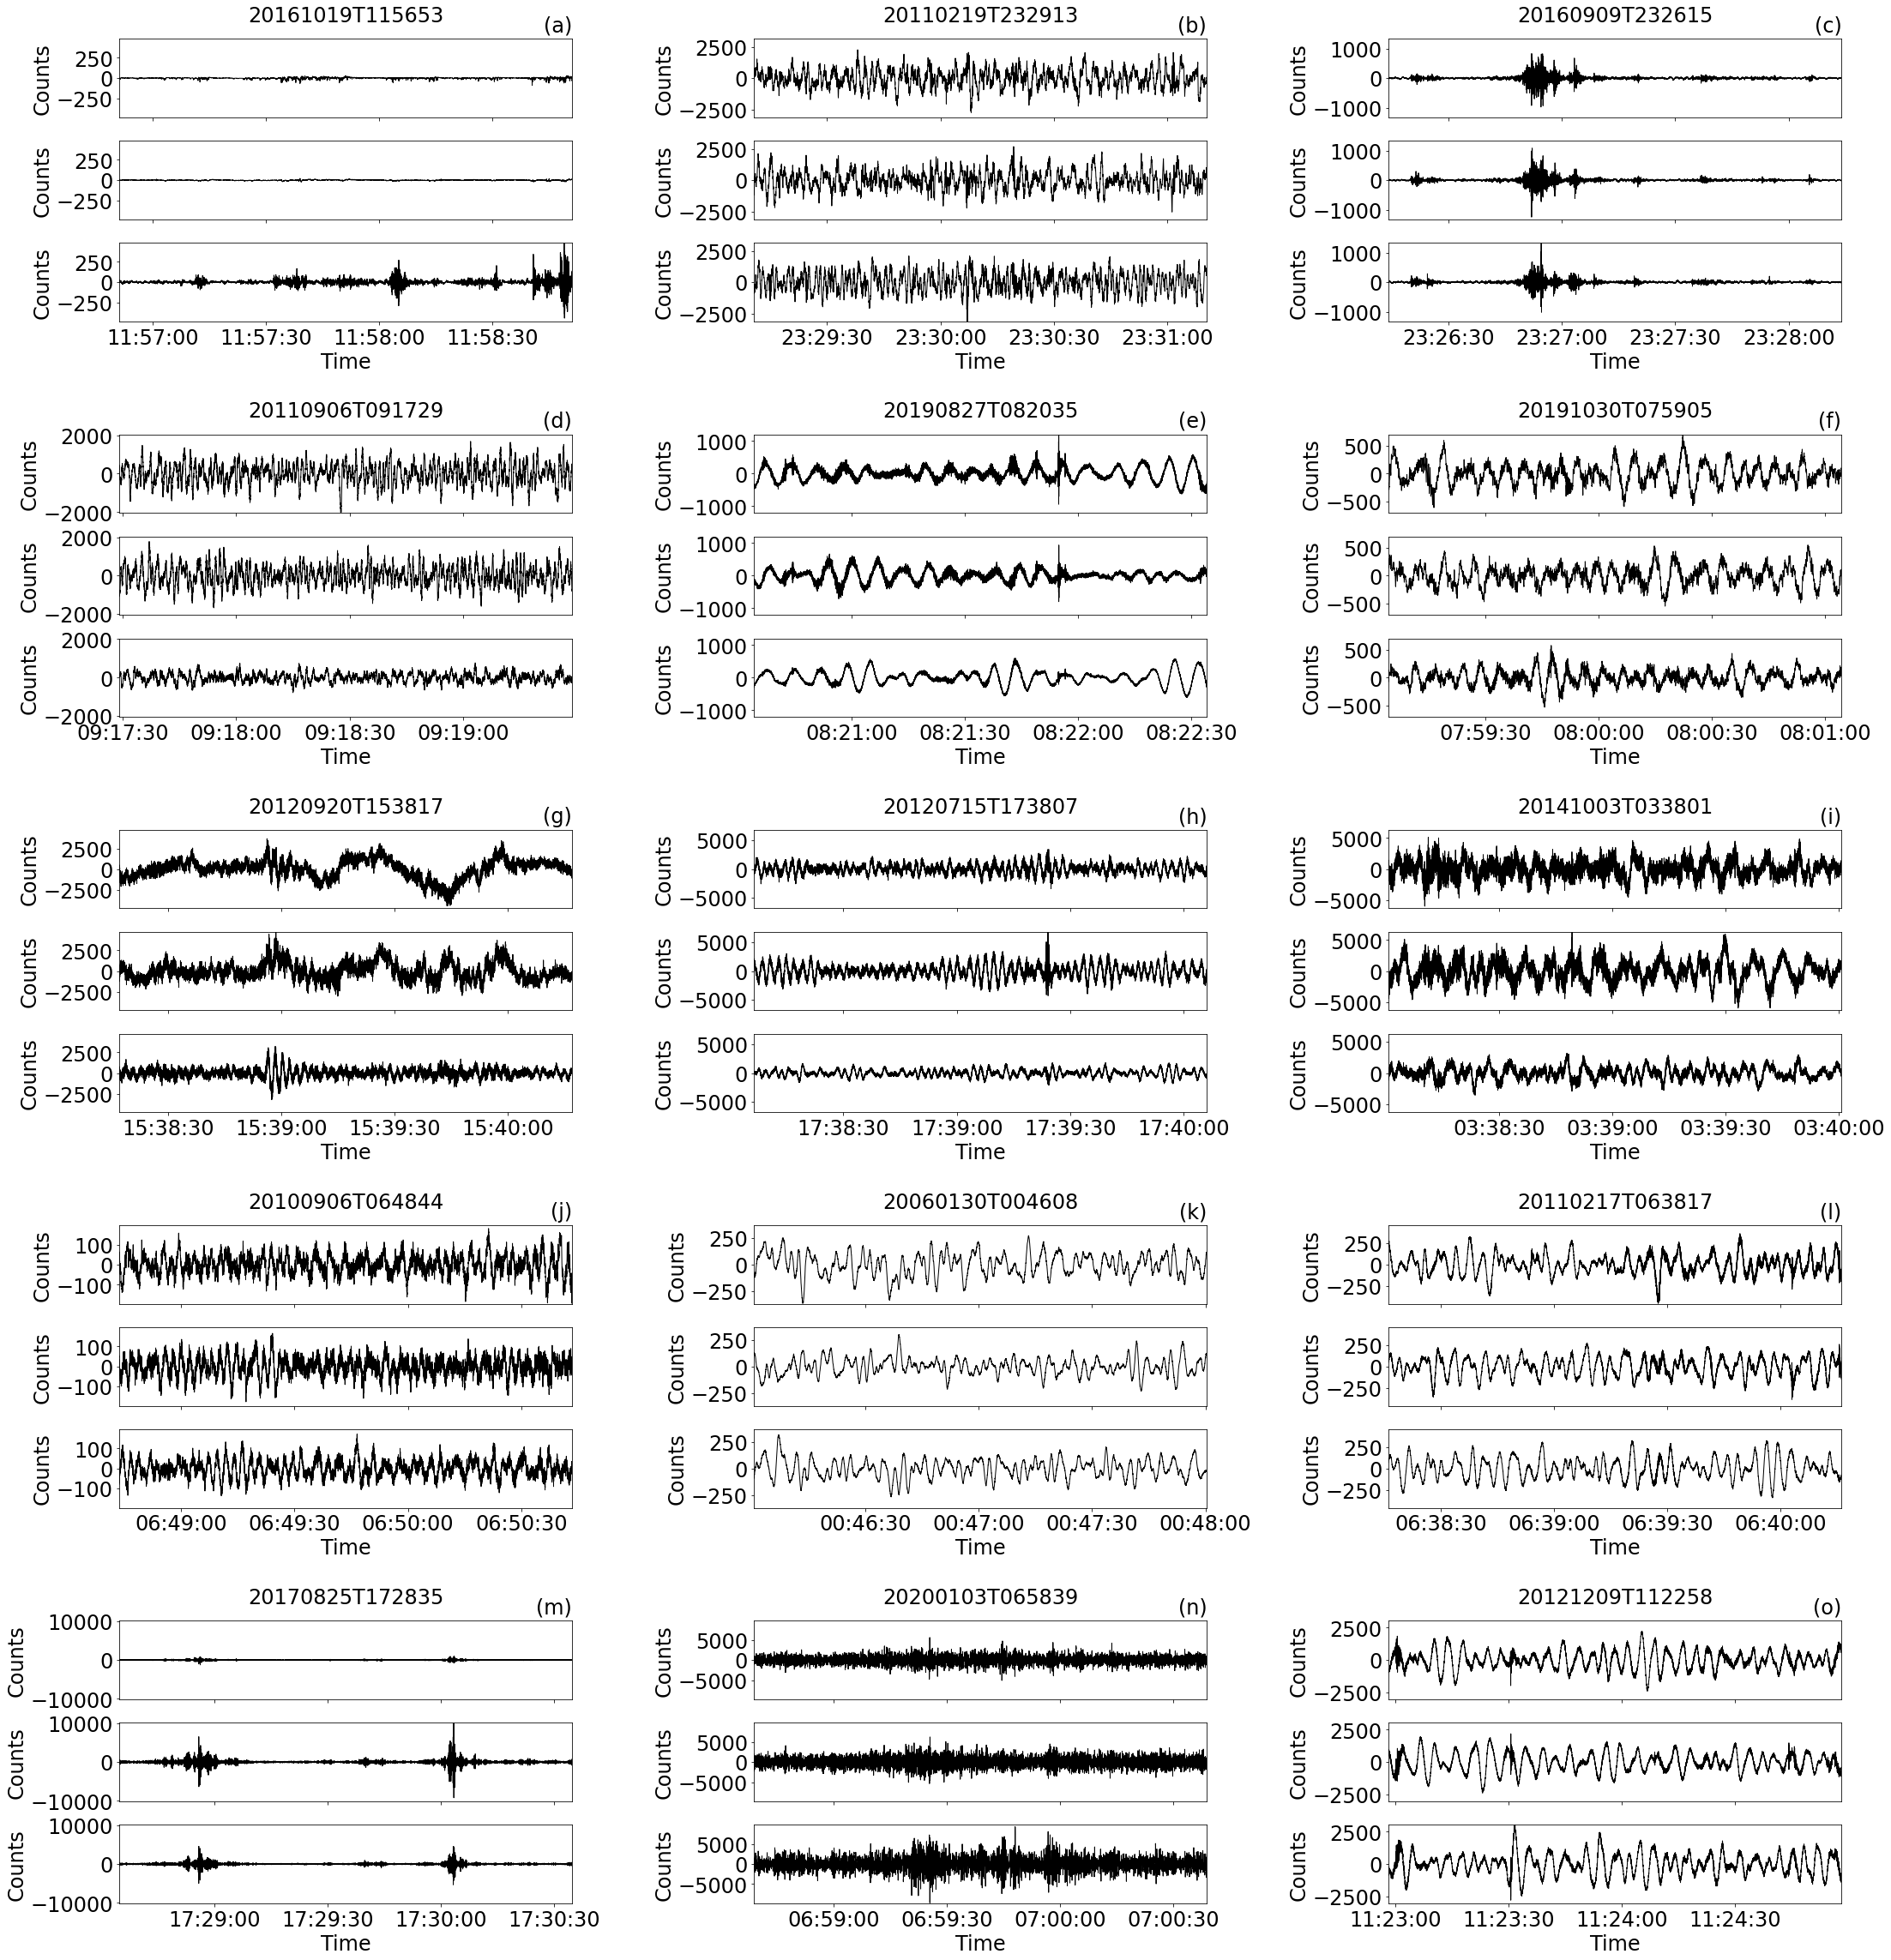

In [64]:
lines = chosen_lines
# Kind of unit
units = len(lines)*["Counts"]


# Do you want the traces filtered?
filt = False
freq_min=3.0
freq_max=20.0

nrow=int(len(lines)/plots_line)
ncol=plots_line
labs = alllabs[:(ncol*nrow)]


wftype = 'noise'
if wftype == 'ev_c':
    df = events_metaData
    h5 = events_h5File
elif wftype == 'ev_gm':
    df = events_metaData
    h5 = gm_h5File
elif wftype == 'noise':
    df = noise_metaData
    h5 = noise_h5File


multiple_streams(df,h5,lines,wftype,nrow,ncol,units,labs,filt,freq_min,freq_max)


noise_figname=os.path.join(FIGDIR,'Fig_20.png')
plt.savefig(noise_figname,dpi=300)

